# Лабораторная работа 5

**Тема:** автоматическое тестирование качества модели машинного обучения с помощью `pytest`.


## Подготовка
```python
!python -m pip install -r requirements.txt
```

Нотбук сам записывает файлы `model_quality.py`, `pytest.ini` и `test_model_quality.py` через `%%writefile`, после чего использует их для анализа и тестирования.

In [13]:
from pathlib import Path
import os
import sys

cwd = Path.cwd().resolve()
project_root = next(path for path in [cwd, *cwd.parents] if (path / "lab5").exists())
lab_dir = project_root / "lab5"

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

os.chdir(lab_dir)
print(f"Project root: {project_root}")
print(f"Working directory: {Path.cwd()}")

Project root: C:\Users\likip\source\repos\Auto_MO_Group_3
Working directory: c:\Users\likip\source\repos\Auto_MO_Group_3\lab5


## Core

In [14]:
%%writefile model_quality.py
from __future__ import annotations

from dataclasses import dataclass

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score


QUALITY_THRESHOLDS = {
    "mae": 0.55,
    "rmse": 0.70,
    "r2": 0.96,
}


@dataclass(frozen=True)
class RegressionDataset:
    name: str
    x: np.ndarray
    y: np.ndarray

    @property
    def features(self) -> np.ndarray:
        return self.x.reshape(-1, 1)


def generate_linear_dataset(
    *,
    name: str,
    seed: int,
    start: float,
    stop: float,
    size: int = 100,
    slope: float = 1.0,
    intercept: float = 0.0,
    noise_scale: float = 0.45,
    noisy_slice: slice | None = None,
    noisy_multiplier: float = 1.0,
) -> RegressionDataset:
    rng = np.random.default_rng(seed)
    x = np.linspace(start, stop, size)
    y = slope * x + intercept + rng.uniform(-noise_scale, noise_scale, size)

    if noisy_slice is not None:
        y[noisy_slice] *= noisy_multiplier

    return RegressionDataset(name=name, x=x, y=y)


def build_clean_datasets() -> dict[str, RegressionDataset]:
    return {
        "train_reference": generate_linear_dataset(
            name="train_reference",
            seed=7,
            start=0.0,
            stop=10.0,
            noise_scale=0.45,
        ),
        "clean_shifted_range": generate_linear_dataset(
            name="clean_shifted_range",
            seed=11,
            start=-5.0,
            stop=5.0,
            noise_scale=0.50,
        ),
        "clean_wide_range": generate_linear_dataset(
            name="clean_wide_range",
            seed=21,
            start=10.0,
            stop=20.0,
            noise_scale=0.35,
        ),
    }


def build_noisy_dataset() -> RegressionDataset:
    return generate_linear_dataset(
        name="noisy_outliers",
        seed=31,
        start=0.0,
        stop=10.0,
        noise_scale=0.45,
        noisy_slice=slice(25, 45),
        noisy_multiplier=2.0,
    )


def train_reference_model(dataset: RegressionDataset) -> LinearRegression:
    model = LinearRegression()
    model.fit(dataset.features, dataset.y)
    return model


def evaluate_model(model: LinearRegression, dataset: RegressionDataset) -> dict[str, float]:
    predictions = model.predict(dataset.features)
    return {
        "mae": float(mean_absolute_error(dataset.y, predictions)),
        "rmse": float(root_mean_squared_error(dataset.y, predictions)),
        "r2": float(r2_score(dataset.y, predictions)),
    }


def assert_quality(metrics: dict[str, float], thresholds: dict[str, float] | None = None) -> None:
    thresholds = thresholds or QUALITY_THRESHOLDS
    assert metrics["mae"] <= thresholds["mae"], (
        f"MAE={metrics['mae']:.3f} is above {thresholds['mae']:.3f}"
    )
    assert metrics["rmse"] <= thresholds["rmse"], (
        f"RMSE={metrics['rmse']:.3f} is above {thresholds['rmse']:.3f}"
    )
    assert metrics["r2"] >= thresholds["r2"], (
        f"R2={metrics['r2']:.3f} is below {thresholds['r2']:.3f}"
    )

Overwriting model_quality.py


In [15]:
%%writefile pytest.ini
[pytest]
addopts = -p no:cacheprovider

Overwriting pytest.ini


In [16]:
import matplotlib.pyplot as plt

from lab5.model_quality import (
    QUALITY_THRESHOLDS,
    assert_quality,
    build_clean_datasets,
    build_noisy_dataset,
    evaluate_model,
    train_reference_model,
)

## Генерация датасетов


In [17]:
clean_datasets = build_clean_datasets()
noisy_dataset = build_noisy_dataset()

for name, dataset in clean_datasets.items():
    print(name, dataset.x.shape, dataset.y.shape)
print(noisy_dataset.name, noisy_dataset.x.shape, noisy_dataset.y.shape)

train_reference (100,) (100,)
clean_shifted_range (100,) (100,)
clean_wide_range (100,) (100,)
noisy_outliers (100,) (100,)


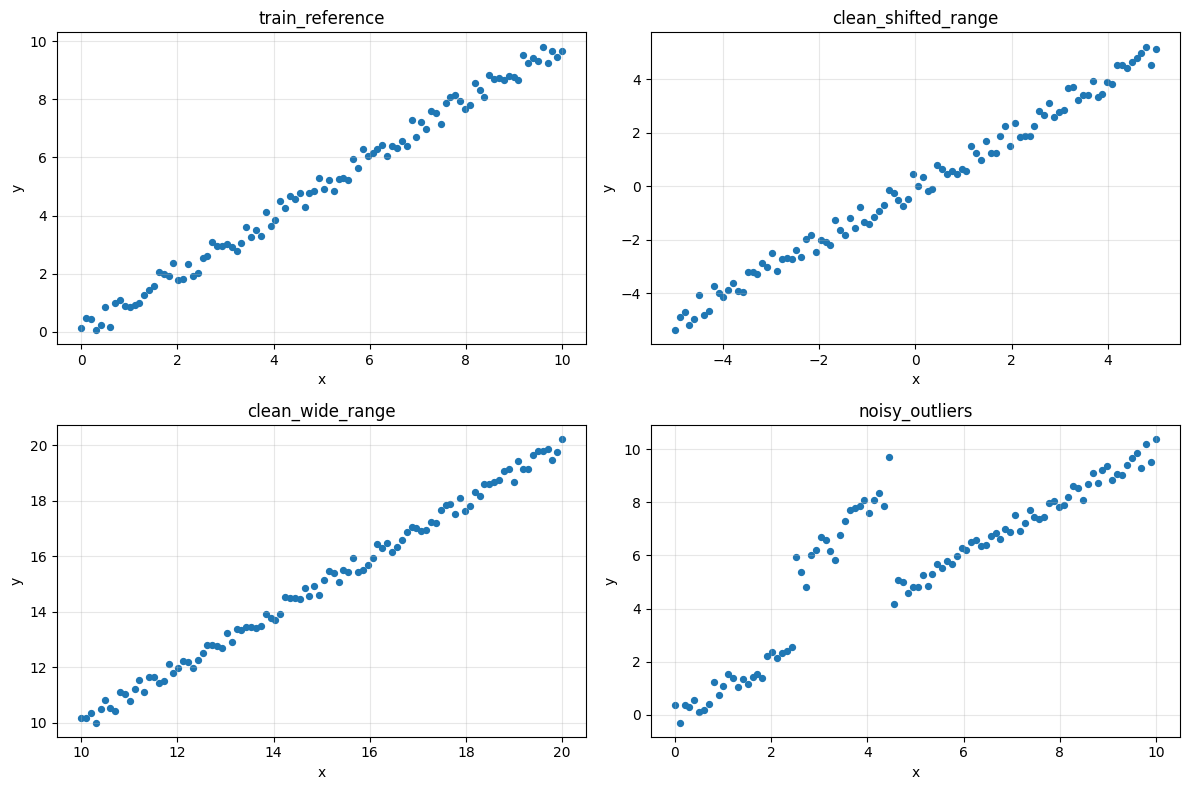

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

all_datasets = list(clean_datasets.values()) + [noisy_dataset]
for ax, dataset in zip(axes, all_datasets):
    ax.scatter(dataset.x, dataset.y, s=18)
    ax.set_title(dataset.name)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Обучение линейной регрессии

Обучаем модель на датасете `train_reference`.

In [19]:
model = train_reference_model(clean_datasets["train_reference"])
print(f"coef = {model.coef_[0]:.4f}")
print(f"intercept = {model.intercept_:.4f}")

coef = 0.9937
intercept = 0.0171


## Анализ качества на разных датасетах

- `MAE` - средняя абсолютная ошибка,
- `RMSE` - корень из средней квадратичной ошибки,
- `R2` - коэффициент детерминации.

Пороговые значения качества задаются в `QUALITY_THRESHOLDS`.

In [20]:
all_metrics = {
    name: evaluate_model(model, dataset)
    for name, dataset in clean_datasets.items()
}
all_metrics[noisy_dataset.name] = evaluate_model(model, noisy_dataset)

print(QUALITY_THRESHOLDS)
print()
for dataset_name, metrics in all_metrics.items():
    print(dataset_name)
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")
    print()

{'mae': 0.55, 'rmse': 0.7, 'r2': 0.96}

train_reference
  mae: 0.2222
  rmse: 0.2594
  r2: 0.9920

clean_shifted_range
  mae: 0.2713
  rmse: 0.3085
  r2: 0.9890

clean_wide_range
  mae: 0.1947
  rmse: 0.2244
  r2: 0.9941

noisy_outliers
  mae: 0.8908
  rmse: 1.6348
  r2: 0.6940



In [21]:
for dataset_name in clean_datasets:
    assert_quality(all_metrics[dataset_name])
    print(f"{dataset_name}: тест качества пройден")

try:
    assert_quality(all_metrics[noisy_dataset.name])
except AssertionError as error:
    print(f"{noisy_dataset.name}: проблема качества -> {error}")

train_reference: тест качества пройден
clean_shifted_range: тест качества пройден
clean_wide_range: тест качества пройден
noisy_outliers: проблема качества -> MAE=0.891 is above 0.550


## Автоматизация через pytest


In [22]:
%%writefile test_model_quality.py
from __future__ import annotations

from statistics import mean

import pytest

from lab5.model_quality import (
    QUALITY_THRESHOLDS,
    assert_quality,
    build_clean_datasets,
    build_noisy_dataset,
    evaluate_model,
    train_reference_model,
)


CLEAN_DATASETS = build_clean_datasets()
MODEL = train_reference_model(CLEAN_DATASETS["train_reference"])
CLEAN_METRICS = {
    name: evaluate_model(MODEL, dataset)
    for name, dataset in CLEAN_DATASETS.items()
}
NOISY_METRICS = evaluate_model(MODEL, build_noisy_dataset())


@pytest.mark.parametrize("dataset_name", CLEAN_METRICS.keys())
def test_clean_datasets_meet_quality_requirements(dataset_name: str) -> None:
    assert_quality(CLEAN_METRICS[dataset_name], QUALITY_THRESHOLDS)


def test_noisy_dataset_breaks_quality_requirements() -> None:
    with pytest.raises(AssertionError):
        assert_quality(NOISY_METRICS, QUALITY_THRESHOLDS)


def test_noisy_dataset_is_much_worse_than_clean_datasets() -> None:
    average_clean_mae = mean(metrics["mae"] for metrics in CLEAN_METRICS.values())
    minimum_clean_r2 = min(metrics["r2"] for metrics in CLEAN_METRICS.values())

    assert NOISY_METRICS["mae"] > average_clean_mae * 3
    assert NOISY_METRICS["r2"] < minimum_clean_r2 - 0.10

Overwriting test_model_quality.py


In [23]:
!python -m pytest -c pytest.ini . -q

.....                                                                    [100%]
5 passed in 2.00s


## Вывод

- модель линейной регрессии успешно обучается на качественном датасете;
- на трёх качественных датасетах значения `MAE`, `RMSE` и `R2` остаются в пределах допустимых порогов;
- на шумном датасете тесты фиксируют существенное ухудшение качества, поэтому проблема в данных обнаруживается автоматически.